# Notebook 1: Análisis dataset 
**Autor:** Ana Gabriela García Rivas

**Fecha:** Junio 2026

**Dataset:** WELFake —  Artículos de noticias (reales y falsas)

En este notebook se realizará el análisis inicial del dataset WELFake, utilizado para la clasificación binaria de noticias reales y falsas. El objetivo principal es la estructura de los datos antes de aplicar técnicas de representación vectorial y modelos de clasificación.

Las etiquetas utilizadas a lo largo del proyecto:

- `label = 0` → noticia real.
- `label = 1` → noticia falsa.

Además debido a la propia naturaleza del dataset, se prestará especial atención a la detección de posibles fuentes de data leakage. Por lo que se revisarán duplicados, solapamientos, términos asociados a fuentes periodísticas y palabras que puedan coincidir directamente con la etiqueta a predecir.


## Descripción general del dataset

El dataset posee noticias etiquetadas como reales o falsas. Cada noticia dispone ítulo y cuerpo, junto la correspondiente etiqueta binaria.

Antes de comenzar el entrenamiento, es necesario inspeccionar el dataset para comprobar:

- Número total de instancias.
- Variables disponibles.
- Presencia de valores nulos.
- Distribución de clases.
- Posibles duplicados.
- Patrones textuales que puedan introducir sesgos o data leakage.

Este análisis inicial es clave para evitar que los modelos aprendan atajos artificiales en lugar de patrones generales de desinformación.

---
### 1. Importación de librerías

In [18]:
#Descarga de librerias necesarias.
!pip install pandas numpy seaborn matplotlib wordcloud nltk scikit-learn datasets

#Importación de librerias.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')
import nltk

from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
from sklearn.model_selection import train_test_split
from datasets import load_dataset

#Configuracion visual global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

#Semilla  reproducibilidad
SEED = 42
print('Librerias cargadas.')

Librerias cargadas.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 2. Carga del dataset 

In [19]:
#Carga del dataset
print('Descargando dataset...')
cargar_datas = load_dataset('davanstrien/WELFake')

#Convertir a pandas
df = cargar_datas['train'].to_pandas()
print(f'Dataset cargado: {len(df):,} filas')
print(df.head(3))

Descargando dataset...
Dataset cargado: 72,134 filas
                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                NaN   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  


---
## 3. Descripción general del dataset

In [20]:

print('Descripción general del dataset:')
print(f'\nNúmero de instancias : {len(df):,}')
print(f'Número de variables  : {df.shape[1]}')
print(f'\nNombres de columnas  : {list(df.columns)}')
print(f'\nTipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nPorcentaje de nulos:')
print((df.isnull().sum() / len(df) * 100).round(2))

Descripción general del dataset:

Número de instancias : 72,134
Número de variables  : 3

Nombres de columnas  : ['title', 'text', 'label']

Tipos de datos:
title      str
text       str
label    int64
dtype: object

Valores nulos por columna:
title    558
text      39
label      0
dtype: int64

Porcentaje de nulos:
title    0.77
text     0.05
label    0.00
dtype: float64


In [21]:
#Renombrar columna 
if 'Unnamed: 0' in df.columns:
    df = df.rename(columns={'Unnamed: 0': 'id'})

#Eliminar filas  nulas
n_inicial = len(df)
df = df.dropna(subset=['text', 'label']).copy()

#Convertir columnas a string
df['text'] = df['text'].astype(str)
df['title'] = df['title'].fillna('').astype(str)
df['text_full'] = (df['title'] + ' ' + df['text']).str.strip()

#Eliminar textos vacios
df = df[df['text_full'].str.len() > 0].copy()

#Eliminar duplicados
n_antes_dup = len(df)
df = df.drop_duplicates(subset=['text_full']).reset_index(drop=True)
n_despues_dup = len(df)

print(f'Filas iniciales: {n_inicial:,}')
print(f'Filas eliminadas por nulos/texto vacio: {n_inicial - n_antes_dup:,}')
print(f'Filas eliminadas por duplicados: {n_antes_dup - n_despues_dup:,}')
print(f'Filas finales tras limpieza: {len(df):,}')


print(f'\nValores unicos en label: {sorted(df["label"].unique())}')

Filas iniciales: 72,134
Filas eliminadas por nulos/texto vacio: 39
Filas eliminadas por duplicados: 8,458
Filas finales tras limpieza: 63,637

Valores unicos en label: [np.int64(0), np.int64(1)]


Se eliminan valores nulos y a su vez los duplicados exactos. Esta decisión es importante porque la presencia de noticias repetidas podría provocar que una misma noticia apareciera en train y test, inflando artificialmente el rendimiento de los modelos.

In [22]:
#Ejemplos por clase
print('Ejemplos de noticias REALES (label=0)')
for _, row in df[df['label'] == 0].head(3).iterrows():
    print(f'  Titular: {row["title"][:80]}...')
    print(f'  Texto  : {row["text"][:120]}...')
    print()

print('Ejemplos de noticias FALSAS (label=1)')
for _, row in df[df['label'] == 1].head(3).iterrows():
    print(f'  Titular: {row["title"][:80]}...')
    print(f'  Texto  : {row["text"][:120]}...')
    print()

Ejemplos de noticias REALES (label=0)
  Titular: Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelica...
  Texto  : A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the ...

  Titular: May Brexit offer would hurt, cost EU citizens - EU parliament...
  Texto  : BRUSSELS (Reuters) - British Prime Minister Theresa May s offer of  settled status  for EU residents is flawed and will ...

  Titular: Schumer calls on Trump to appoint official to oversee Puerto Rico relief...
  Texto  : WASHINGTON (Reuters) - Charles Schumer, the top Democrat in the U.S. Senate, called on President Donald Trump on Sunday ...

Ejemplos de noticias FALSAS (label=1)
  Titular: LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11B...
  Texto  : No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for...

  Titular: ...
  Texto  : D

---
## 4. Distribución de clases

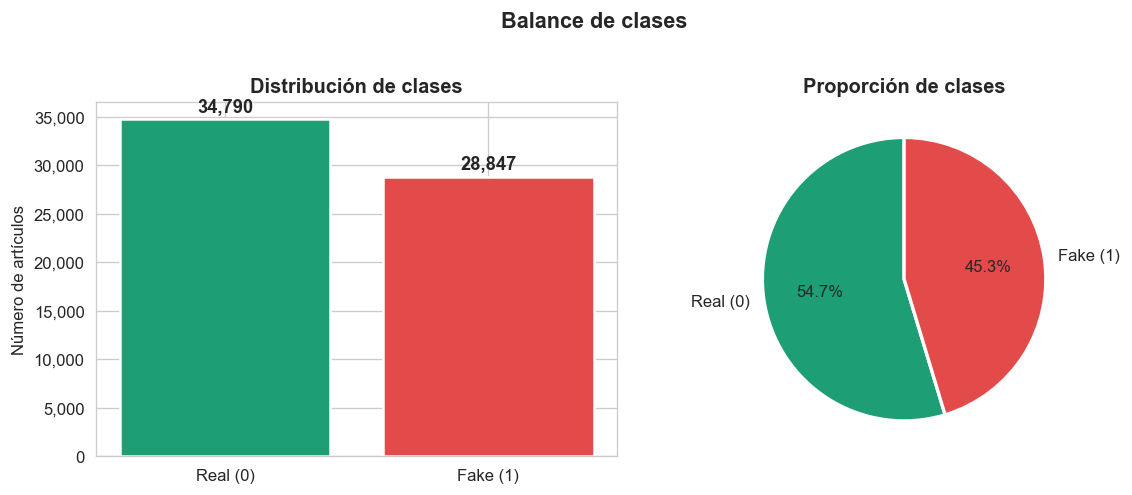

Real: 34,790 (54.7%)
Fake: 28,847 (45.3%)


In [23]:
counts = df['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
nombre_class = {0: 'Real (0)', 1: 'Fake (1)'}
colors = ['#1D9E75', '#E24B4A']

#Grafico barras
barra = axes[0].bar(
    [nombre_class[k] for k in counts.index],
    counts.values,
    color=colors, edgecolor='white', linewidth=1.5
)
for bar, val in zip(barra, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Distribución de clases', fontweight='bold')
axes[0].set_ylabel('Número de artículos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

#Grafico circular
axes[1].pie(
    counts.values,
    labels=[nombre_class[k] for k in counts.index],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de clases', fontweight='bold')

plt.suptitle('Balance de clases', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_distribucion_clases.png', bbox_inches='tight')
plt.show()
print(f'Real: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'Fake: {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')




La distribución de clases es relativamente equilibrada, aunque existe una ligera mayoría de noticias reales frente a falsas. Esta proporción permite entrenar modelos supervisados sin necesidad de aplicar técnicas agresivas de balanceo como oversampling o undersampling.

No obstante, al evaluar los modelos se utilizarán métricas como `F1-score` y `ROC-AUC`, además de `accuracy`, para evitar que la evaluación dependa únicamente de la clase mayoritaria.

---
## 5. Análisis de longitud de textos

In [24]:

df['len_text'] = df['text'].apply(lambda x: len(x.split()))
df['len_title'] = df['title'].apply(lambda x: len(x.split()))

print('Estadísticas de longitud del TEXTO (palabras):')
print(df.groupby('label')['len_text'].describe().round(1).rename(index={0:'Real', 1:'Fake'}))

print('\nEstadísticas de longitud del TITULAR (palabras):')
print(df.groupby('label')['len_title'].describe().round(1).rename(index={0:'Real', 1:'Fake'}))

Estadísticas de longitud del TEXTO (palabras):
         count   mean    std  min    25%    50%    75%      max
label                                                          
Real   34790.0  578.3  564.4  0.0  241.0  427.0  784.0  14641.0
Fake   28847.0  499.7  659.2  0.0  230.0  374.0  558.0  24234.0

Estadísticas de longitud del TITULAR (palabras):
         count  mean  std  min   25%   50%   75%   max
label                                                 
Real   34790.0  11.1  2.9  2.0   9.0  11.0  13.0  30.0
Fake   28847.0  12.9  4.8  0.0  10.0  13.0  15.0  72.0


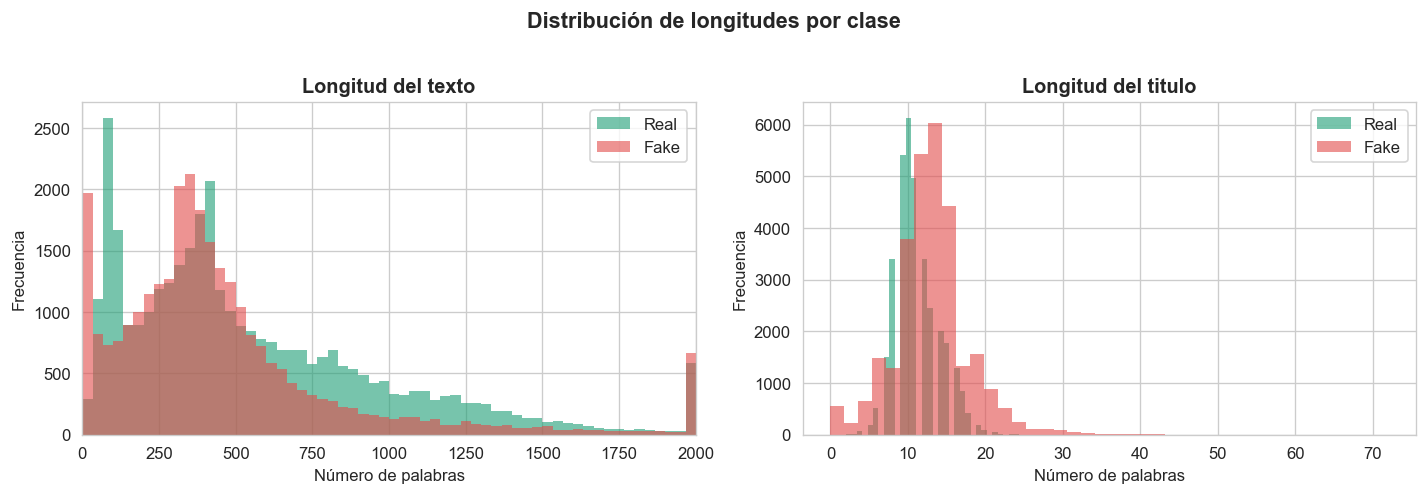

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color, name in [(0, '#1D9E75', 'Real'), (1, '#E24B4A', 'Fake')]:
    subset = df[df['label'] == label]['len_text'].clip(upper=2000)
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=name, edgecolor='none')
axes[0].set_title('Longitud del texto', fontweight='bold')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].set_xlim(0, 2000)

#Histograma de longitud de titular
for label, color, name in [(0, '#1D9E75', 'Real'), (1, '#E24B4A', 'Fake')]:
    subset = df[df['label'] == label]['len_title']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='none')
axes[1].set_title('Longitud del titulo', fontweight='bold')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Distribución de longitudes por clase', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_longitudes.png', bbox_inches='tight')
plt.show()


El análisis de longitudes muestra que las noticias presentan una variabilidad considerable en el número de palabras. Las noticias reales tienden a tener cuerpos de texto algo más largos, mientras que las noticias falsas pueden presentar titulares ligeramente más extensos.

Estas diferencias pueden aportar información útil a los modelos, aunque no deben interpretarse como un criterio suficiente para clasificar una noticia. La longitud se considera únicamente una señal exploratoria, no una regla de decisión.

---
## 6. Análisis preliminar del texto

In [26]:

STOP_WORDS = set(stopwords.words('english'))

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'[^a-z\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    palabras = [p for p in texto.split() if p not in STOP_WORDS and len(p) > 2]
    return palabras

#Una muestra para facilitar el análisis de palabras sin procesar
sample_size = min(10000, len(df))
muestra_texto = df.sample(sample_size, random_state=SEED)

#Separar palabras por clase
fake_words = []
real_words = []

for _, row in muestra_texto.iterrows():
    palabras = limpiar_texto(row['text_full'])

    if row['label'] == 1:
        fake_words.extend(palabras)
    else:
        real_words.extend(palabras)

print(f'Palabras en noticias fake: {len(fake_words):,}')
print(f'Palabras en noticias reales: {len(real_words):,}')

Palabras en noticias fake: 1,230,709
Palabras en noticias reales: 1,838,682


Top fake encontrados: 20
Top real encontrados: 20


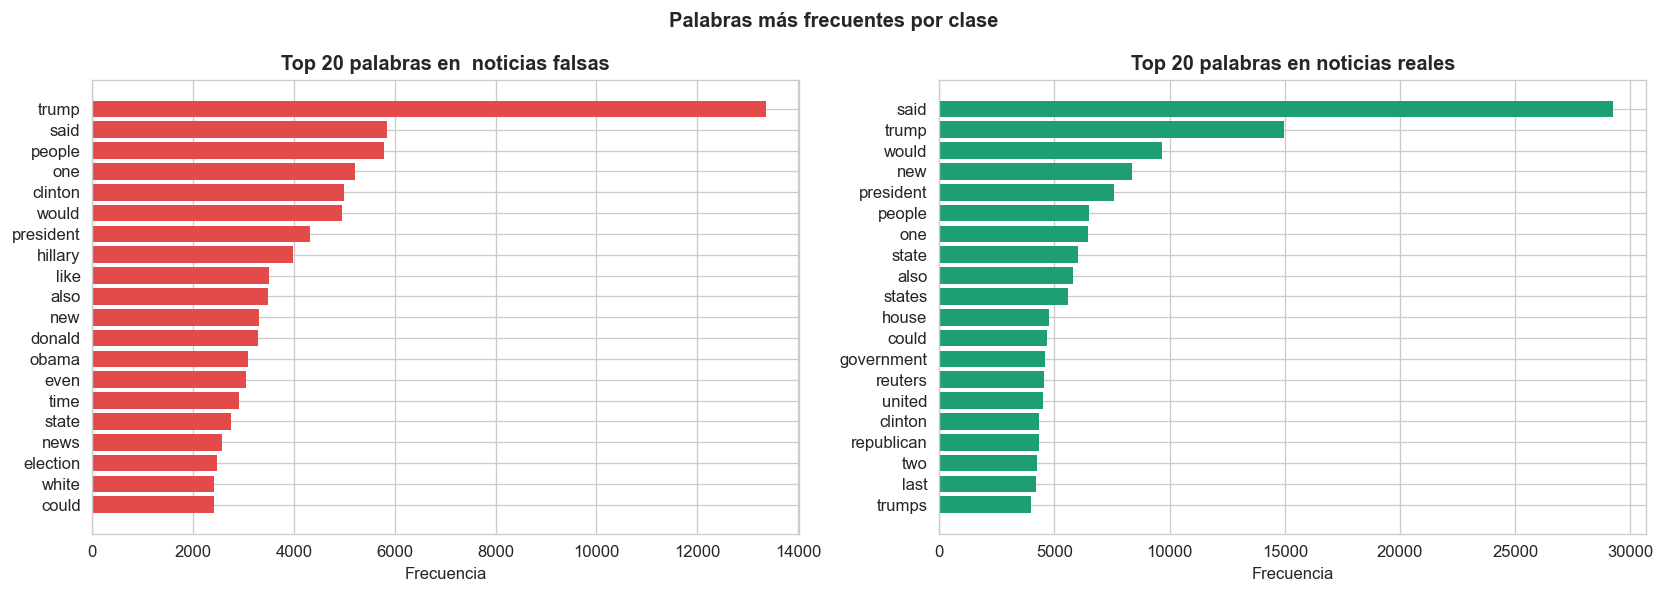

In [27]:
#Top 20 palabras más frecuentes por clase
top_fake = Counter(fake_words).most_common(20)
top_real = Counter(real_words).most_common(20)

print(f'Top fake encontrados: {len(top_fake)}')
print(f'Top real encontrados: {len(top_real)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Noticias falsas
if len(top_fake) > 0:
    palabras_f, freqs_f = zip(*top_fake)
    axes[0].barh(
        list(reversed(palabras_f)),
        list(reversed(freqs_f)),
        color='#E24B4A',
        edgecolor='none'
    )
    axes[0].set_title('Top 20 palabras en  noticias falsas', fontweight='bold')
    axes[0].set_xlabel('Frecuencia')
else:
    axes[0].text(0.5, 0.5, 'No hay palabras fake', ha='center', va='center')
    axes[0].set_title('Noticias falsas')

#Noticias reales
if len(top_real) > 0:
    palabras_r, freqs_r = zip(*top_real)
    axes[1].barh(
        list(reversed(palabras_r)),
        list(reversed(freqs_r)),
        color='#1D9E75',
        edgecolor='none'
    )
    axes[1].set_title('Top 20 palabras en noticias reales', fontweight='bold')
    axes[1].set_xlabel('Frecuencia')
else:
    axes[1].text(0.5, 0.5, 'No hay palabras reales', ha='center', va='center')
    axes[1].set_title('Noticias reales')

plt.suptitle('Palabras más frecuentes por clase', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_palabras_frecuentes.png', bbox_inches='tight')
plt.show()

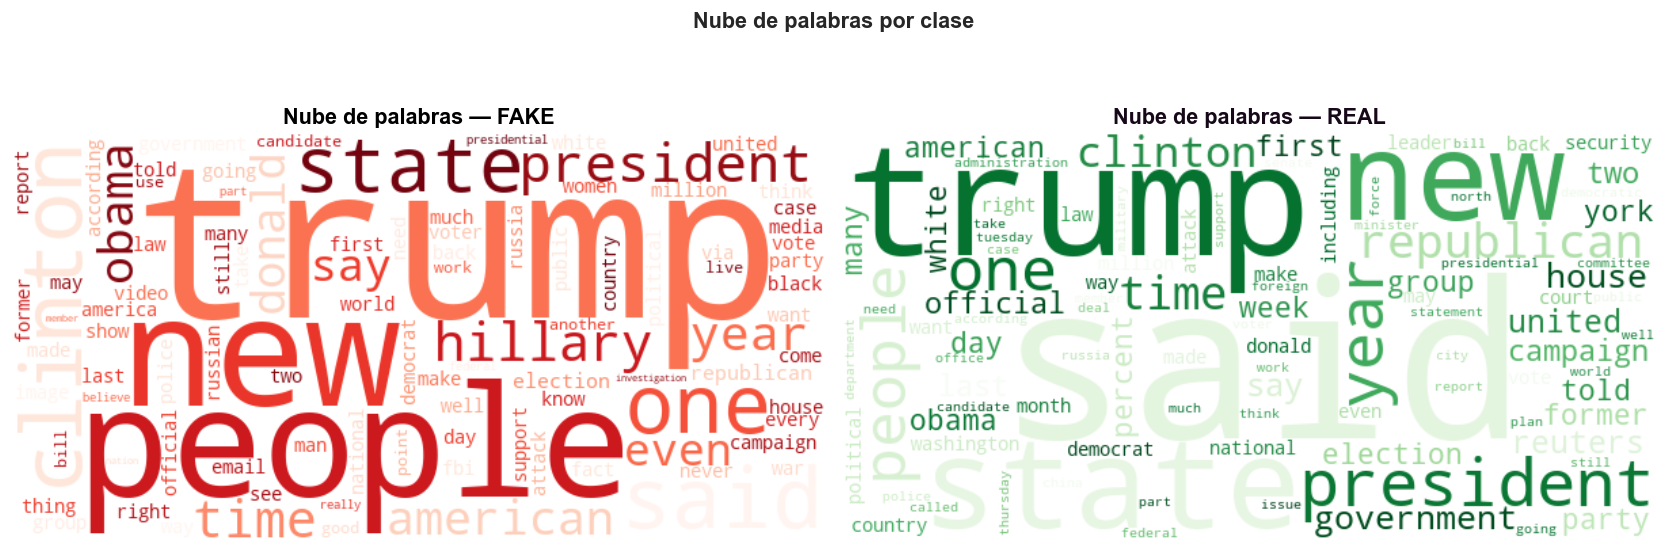

In [28]:
#Nubes de palabras
def crear_nube(words_list, colormap, title):
    text = ' '.join(words_list)
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(text)
    return wc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cloud_fak = crear_nube(fake_words, 'Reds', 'Fake')
cloud_real = crear_nube(real_words, 'Greens', 'Real')

axes[0].imshow(cloud_fak, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Nube de palabras — FAKE', fontsize=13, fontweight='bold', color="#000000")

axes[1].imshow(cloud_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nube de palabras — REAL', fontsize=13, fontweight='bold', color="#160818")

plt.suptitle('Nube de palabras por clase', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_wordclouds.png', bbox_inches='tight')
plt.show()

El análisis de palabras frecuentes debe interpretarse como exploratorio. Las noticias reales son más numerosas y tienen mayor longitud media, por lo que acumulan más palabras totales que las falsas. Por este motivo, las frecuencias absolutas no deben interpretarse como una medida directa de importancia discriminativa. En los notebooks siguientes se utilizarán representaciones como TF-IDF, Word2Vec y embeddings contextuales para comparar los textos de forma más robusta.

In [29]:
#Palabras exclusivas de cada clase 
top_fake_set = set([w for w, _ in Counter(fake_words).most_common(200)])
top_real_set = set([w for w, _ in Counter(real_words).most_common(200)])

solo_fake = top_fake_set - top_real_set
solo_real = top_real_set - top_fake_set

print('Palabras relevantes unicamente en noticias FALSAS (primeras 20):')
print(sorted(solo_fake)[:20])

print('\nPalabras relevantes unicamente en noticias REALES (primeras 20):')
print(sorted(solo_real)[:20])

Palabras relevantes unicamente en noticias FALSAS (primeras 20):
['actually', 'already', 'america', 'away', 'believe', 'big', 'black', 'children', 'clintons', 'comey', 'course', 'email', 'emails', 'ever', 'fact', 'fbi', 'fox', 'gop', 'got', 'great']

Palabras relevantes unicamente en noticias REALES (primeras 20):
['added', 'among', 'business', 'came', 'chief', 'china', 'committee', 'company', 'congress', 'countries', 'deal', 'decision', 'director', 'executive', 'forces', 'four', 'friday', 'general', 'groups', 'home']


In [30]:
#Análisis de data leakage 

term_fuente = [
    'reuters', 'associated press', 'ap', 'bbc', 'cnn', 'fox news',
    'washington post', 'new york times', 'politifact', 'snopes',
    'breitbart', 'infowars', 'natural news', 'beforeitsnews',
    'worldnewsdailyreport', 'yournewswire', 'activistpost'
]

textos = df['text_full'].fillna('').astype(str).str.lower()
resultados_leakage = []

for term in term_fuente:
    patron = r'\b' + re.escape(term) + r'\b' if ' ' not in term else re.escape(term)
    aparece = textos.str.contains(patron, regex=True)

    n_real = df[(df['label'] == 0) & aparece].shape[0]
    n_fake = df[(df['label'] == 1) & aparece].shape[0]
    total = n_real + n_fake

    if total > 0:
        resul_real = n_real / total * 100
        resul_fake = n_fake / total * 100

        resultados_leakage.append({
            'Término': term,
            'En real': n_real,
            'En fake': n_fake,
            'Total': total,
            '% en real': round(resul_real, 1),
            '% en fake': round(resul_fake, 1),
            'Riesgo leakage': 'ALTO' if (resul_fake > 85 or resul_fake < 15) else 'bajo'
        })

df_leakage = pd.DataFrame(resultados_leakage)

if len(df_leakage) > 0:
    df_leakage = df_leakage.sort_values(['Riesgo leakage', 'Total'], ascending=[True, False])
    print(df_leakage.to_string(index=False))

    alto_riesgo = df_leakage[df_leakage['Riesgo leakage'] == 'ALTO']['Término'].tolist()
    print(f'\nTerminos de ALTO riesgo de leakage: {alto_riesgo}')
else:
    print('No se encontro ninguno de los terminos candidatos en el dataset.')
    alto_riesgo = []



         Término  En real  En fake  Total  % en real  % en fake Riesgo leakage
         reuters    21423      479  21902       97.8        2.2           ALTO
        infowars       21      195    216        9.7       90.3           ALTO
    natural news        0       48     48        0.0      100.0           ALTO
    yournewswire        0       26     26        0.0      100.0           ALTO
    activistpost        0       11     11        0.0      100.0           ALTO
   beforeitsnews        0        8      8        0.0      100.0           ALTO
  new york times     7234     1395   8629       83.8       16.2           bajo
       breitbart     3357      923   4280       78.4       21.6           bajo
             cnn     1851     2178   4029       45.9       54.1           bajo
        fox news     1484     1864   3348       44.3       55.7           bajo
 washington post     1050     1196   2246       46.7       53.3           bajo
associated press      648      348    996       65.1



El análisis de términos asociados a fuentes demuestra que algunas palabras aparecen de forma muy concentrada en una clase. Por ejemplo, `reuters` aparece mayoritariamente en noticias reales, mientras que términos como `infowars`, `natural news`, `yournewswire`, `activistpost` o `beforeitsnews` aparecen mayoritariamente en noticias falsas.

Esto supone un riesgo metodológico, debido a que los modelos podrían aprender a clasificar noticias a partir de la fuente o del dominio, en lugar de aprender patrones generales de desinformación. Este fenómeno puede inflar artificialmente las métricas si no se controla.

Para reducir este riesgo, estos términos se documentan como posibles atajos léxicos y se eliminarán en los notebooks posteriores dentro de una lista controlada de términos de alto riesgo. Esta mitigación se aplicará en TF-IDF, Word2Vec, embeddings BERT y fine-tuning.

In [31]:
#Análisis de posible leakage por palabras que coinciden con etiquetas
TERMINOS_ETIQUETA = [
    'fake', 'false', 'partially false',
    'true', 'real',
    'label', 'category'
]

texto_min = df['text_full'].fillna('').astype(str).str.lower()

result_var_leak = []

for term in TERMINOS_ETIQUETA:
    palabras = term.split()
    patron = r'\b' + r'\s+'.join(re.escape(p) for p in palabras) + r'\b'

    aparece = texto_min.str.contains(patron, regex=True)

    n_real = df[(df['label'] == 0) & aparece].shape[0]
    n_fake = df[(df['label'] == 1) & aparece].shape[0]
    total = n_real + n_fake

    if total > 0:
        resul_fake = n_fake / total * 100
        resul_real = n_real / total * 100

        result_var_leak.append({
            'Término': term,
            'En real': n_real,
            'En fake': n_fake,
            'Total': total,
            '% fake': round(resul_fake, 1),
            '% real': round(resul_real, 1),
            'Riesgo': 'ALTO' if resul_fake > 85 or resul_fake < 15 else 'moderado'
        })

df_label_leakage = pd.DataFrame(result_var_leak)

if len(df_label_leakage) > 0:
    display(df_label_leakage.sort_values(['Riesgo', 'Total'], ascending=[True, False]))
else:
    print('No se han encontrado terminos de etiqueta en los textos.')


,Término,En real,En fake,Total,% fake,% real,Riesgo
3,real,3812,4168,7980,52.2,47.8,moderado
2,true,1821,2821,4642,60.8,39.2,moderado
1,false,995,1348,2343,57.5,42.5,moderado
0,fake,763,1399,2162,64.7,35.3,moderado
5,category,361,182,543,33.5,66.5,moderado
4,label,301,216,517,41.8,58.2,moderado




Además de los términos de fuente, se revisan palabras que podrían coincidir directamente con las etiquetas del problema, como `fake`, `false`, `true`, `real`, `label` o `category`.

El objetivo de este análisis es comprobar si alguna palabra aparece de forma casi exclusiva en una clase y, por tanto, podría funcionar como una pista directa de la etiqueta. En los resultados obtenidos, estos términos no aparecen de forma completamente exclusiva en una sola clase, por lo que no se detecta una fuga directa de etiqueta.

Como medida preventiva, estas palabras se eliminarán en las representaciones posteriores. De este modo se reduce el riesgo de que los modelos aprendan atajos basados en palabras que indiquen explícitamente la clase a predecir.

## Hipótesis iniciales

A partir del análisis exploratorio se plantean las siguientes hipótesis:

**Hipótesis 1: Diferencias léxicas entre noticias reales y falsas.**  
Se espera que las noticias reales y falsas presenten diferencias en el vocabulario utilizado, expresiones frecuentes, nombres propios, fuentes o estilo de redacción. Lo esperado es que si esta hipótesis se cumple, representaciones como TF-IDF funcionen bien.

**Hipótesis 2: Clasificación automática de modelos supervisados.**  
Se plantea que los modelos supervisados serán capaces de distinguir entre noticias reales y falsas con un rendimiento superior al azar, debido a la existencia de patrones lingüísticos, temáticos y estilísticos en los textos.

**Hipótesis 3: Ventaja de modelos contextuales cuando se ajustan directamente a la tarea.**  
Se espera que los modelos basados en Transformers puedan mejorar los resultados al capturar relaciones contextuales entre palabras. Se analizará si es suficiente con usar embeddings BERT o si el fine-tuning aportará una mejora significativa.

**Hipótesis 4: Relación entre desinformación y polarización lingüística.**  
Se plantea que las noticias falsas pueden presentar mayor carga política, emocional o conflictiva. Esta hipótesis se estudiará en la extensión mediante clustering temático y indicadores de polarización lingüística.

---
## 8. Preparación del split train / validation / test

Dividimos el dataset en tres conjuntos: 80% entrenamiento, 10% validación y 10% test. La división se realiza de forma estructurada para mantener la proporción de clases en los tres subconjuntos.

In [32]:
X = df['text_full']
y = df['label']

#80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

train_df = df.loc[X_train.index].copy()
val_df = df.loc[X_val.index].copy()
test_df = df.loc[X_test.index].copy()

print(f'Train : {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)')

print(f'\nBalance en train → Real: {(train_df["label"]==0).sum():,} | Fake: {(train_df["label"]==1).sum():,}')
print(f'Balance en val   → Real: {(val_df["label"]==0).sum():,} | Fake: {(val_df["label"]==1).sum():,}')
print(f'Balance en test  → Real: {(test_df["label"]==0).sum():,} | Fake: {(test_df["label"]==1).sum():,}')

Train : 50,909 (80.0%)
Val   : 6,364 (10.0%)
Test  : 6,364 (10.0%)

Balance en train → Real: 27,832 | Fake: 23,077
Balance en val   → Real: 3,479 | Fake: 2,885
Balance en test  → Real: 3,479 | Fake: 2,885


In [33]:
def comprobar_solapamiento(df_a, df_b, nombre_a, nombre_b):
    textos_a = set(df_a['text_full'])
    textos_b = set(df_b['text_full'])
    solape = textos_a.intersection(textos_b)
    print(f'Solapamiento {nombre_a}-{nombre_b}: {len(solape)} textos')
    return len(solape)

s1 = comprobar_solapamiento(train_df, val_df, 'train', 'val')
s2 = comprobar_solapamiento(train_df, test_df, 'train', 'test')
s3 = comprobar_solapamiento(val_df, test_df, 'val', 'test')

if s1 == 0 and s2 == 0 and s3 == 0:
    print('\n No hay solapamiento exacto entre train, validation y test.')
else:
    print('\n Hay solapamiento entre particiones.')

Solapamiento train-val: 0 textos
Solapamiento train-test: 0 textos
Solapamiento val-test: 0 textos

 No hay solapamiento exacto entre train, validation y test.


In [34]:
#Seleccionamos columnas finales para los notebooks siguientes.
columnas_salida = ['text_full', 'text', 'title', 'label', 'len_text', 'len_title']

train_df[columnas_salida].to_csv('welfake_train.csv', index=False)
val_df[columnas_salida].to_csv('welfake_val.csv', index=False)
test_df[columnas_salida].to_csv('welfake_test.csv', index=False)

print('  welfake_train.csv')
print('  welfake_val.csv')
print('  welfake_test.csv')

  welfake_train.csv
  welfake_val.csv
  welfake_test.csv


## Conclusión del Notebook 1

El análisis exploratorio muestra que WELFake es un dataset amplio y relativamente equilibrado para clasificación binaria de noticias reales y falsas. Tras eliminar valores nulos y duplicados exactos, se obtiene un conjunto limpio de 63.637 noticias.

Se detectan posibles atajos de fuente, especialmente términos como `reuters` para noticias reales y `infowars`, `natural news`, `yournewswire`, `activistpost` o `beforeitsnews` para noticias falsas. También se revisan palabras que podrían coincidir con las etiquetas, como `fake`, `false`, `true` y `real`. Estas palabras no aparecen de forma exclusiva en una sola clase, pero se filtrarán igualmente como medida conservadora.

El dataset queda dividido en train, validation y test, sin solapamiento entre particiones. 